# 04 · Live Deal Report
Loads the serialized artifacts and runs the **DealDetector** over listings to produce ranked buy/skip recommendations — the product. (Uses the latest scrape as the 'fresh' batch so the notebook runs offline; the commented cell shows the true live path.)

In [1]:
import os, sys
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, ROOT)
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.max_columns', 30); pd.set_option('display.width', 120)
%matplotlib inline

In [2]:
from src.config import load_config
from src.investment import DealDetector
from src.data import load_parquet, latest_parquet
from src.features.parser import is_accessory_listing
from src.reporting import render_deals, default_title
cfg = load_config()
detector = DealDetector.from_artifacts(cfg)
df = load_parquet(latest_parquet('data/raw','wallapop_iphones'))
df = df[~df.title.fillna('').map(is_accessory_listing)]
df = df[df.title.str.contains('13 Pro', case=False, na=False) & df.price.between(50,800)]
print('candidate listings:', len(df))

candidate listings: 787


In [3]:
# --- the true live path (uncomment to scrape fresh listings now) ---
# from src.scrapers import WallapopScraper
# wp = WallapopScraper(cfg.scraping['wallapop'], cfg.cities)
# df = pd.DataFrame([l.as_row() for l in wp.scrape('iPhone 13 Pro','madrid')])

### Ranked deals

In [4]:
deals = detector.detect(df)
print(render_deals(deals, title=default_title('iPhone 13 Pro','madrid'), top=8))

╔══════════════════════════════════════════════════════════════════╗
║   TOP DEALS — iPhone 13 Pro — Madrid — 2026-06-18                ║
╠══════════════════════════════════════════════════════════════════╣
║  #1 🟢 €300 — iPhone 13 Pro Max 256 GB Azul Turquesa              ║
║      Fair: €492 [323–501]                                        ║
║      Margin: +57.5%   Conf: LOW   Score: 0.76  → STRONG BUY      ║
║      Risk flags: none                                            ║
║      → https://es.wallapop.com/item/iphone-13-pro-max-256-gb-azu ║
╠══════════════════════════════════════════════════════════════════╣
║  #2 🟢 €150 — iPhone 13 Pro Dorado                                ║
║      Fair: €274 [222–293]                                        ║
║      Margin: +73.8%   Conf: MEDIUM   Score: 0.75  → STRONG BUY   ║
║      Risk flags: damaged / for parts                             ║
║      → https://es.wallapop.com/item/iphone-13-pro-dorado-1272535 ║
╠═════════════════════════════════

### Score distribution & decision mix

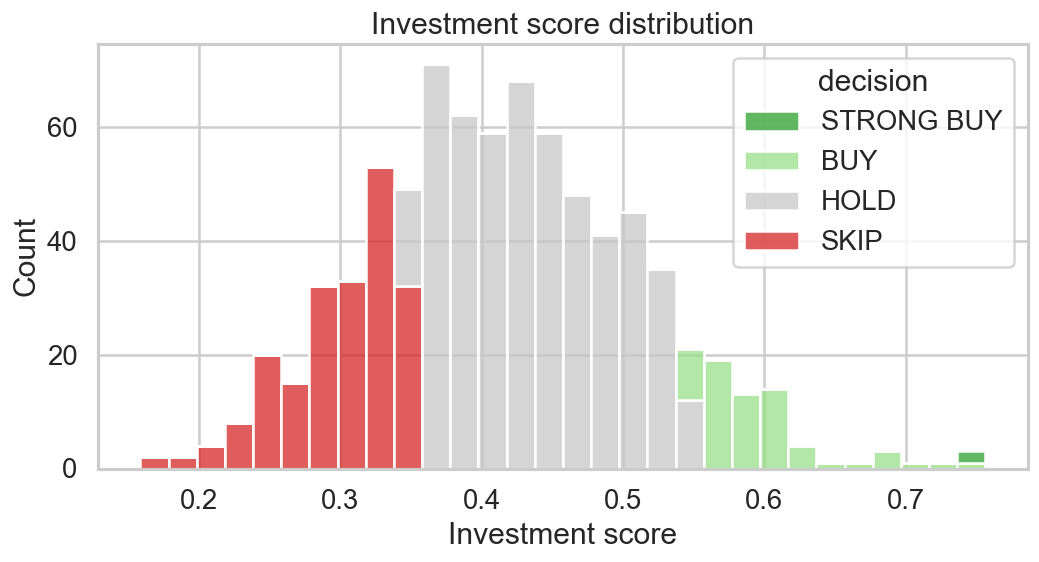

In [5]:
from src.reporting import viz
scores = [d.investment_score for d in deals]; decs = [d.decision for d in deals]
p = viz.score_distribution(scores, decs, 'artifacts/reports/nb_scores.png')
from IPython.display import Image; Image(str(p))

In [6]:
pd.Series(decs).value_counts().to_frame('n_listings')

,n_listings
HOLD,517
SKIP,201
BUY,67
STRONG BUY,2


### Manual spot-check (presentation walkthrough)
For the top deal, compare the model's fair-value estimate against the listing price and the 80% interval. In the live demo this is cross-checked against the eBay and Backmarket price for the same model/condition.

In [7]:
top = deals[0]
import json; print(json.dumps(top.to_dict(), indent=2, ensure_ascii=False)[:700])

{
  "listing_id": "pj947o1wgm6e",
  "title": "iPhone 13 Pro Max 256 GB Azul Turquesa",
  "asking_price": 299.99,
  "predicted_fair_price": 492.36,
  "price_low": 322.61,
  "price_high": 500.51,
  "expected_margin": 0.5753,
  "confidence": 0.2773,
  "risk_score": 0.0,
  "investment_score": 0.7565,
  "decision": "STRONG BUY",
  "risk_flags": [],
  "city": "Madrid",
  "url": "https://es.wallapop.com/item/iphone-13-pro-max-256-gb-azul-turquesa-1273312013"
}


> **Disclaimer.** Academic project; the investment score is not financial advice and the model cannot verify authenticity. Do your own due diligence.